# To develop a predictive model that estimates the Medical Insurance Premium (Charges) for individuals based on their demographic and health characteristics.


# This dataset contents total 7 columns age, sex, bmi, children, smoker, region, charges

# machine learning 


In [25]:
%pip install scikit-learn

In [27]:
import sklearn
print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.7.0


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('medical_cost.zip')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 57.6+ KB


In [9]:
total_nulls = df.isnull().sum().sum()
total_nulls

np.int64(0)

In [10]:
has_any_nulls = df.isnull().any().any()     # returns true if any null exists, false otherwise
has_any_nulls

np.False_

In [11]:
df.shape

(1338, 7)

# basic data visualization
# histogram = frequncy

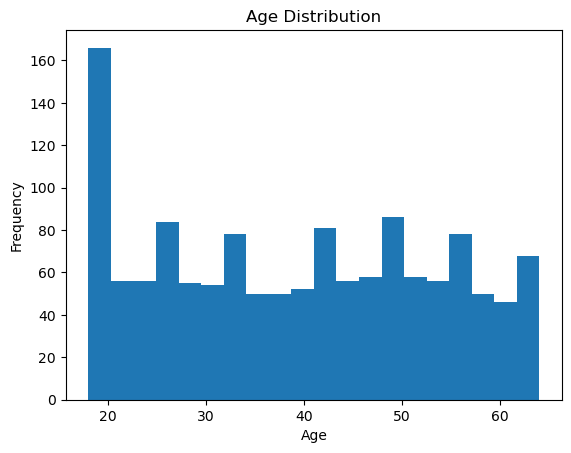

In [12]:
# 1. histogram of age
plt.figure()
plt.hist(df['age'], bins = 20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

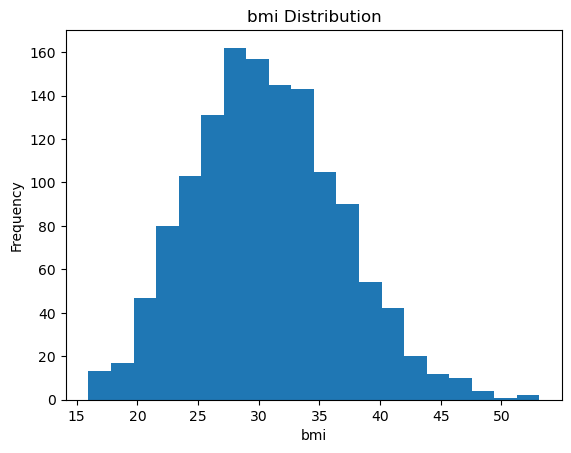

In [13]:
# 1. histogram of bmi
plt.figure()
plt.hist(df['bmi'], bins = 20)
plt.title("bmi Distribution")
plt.xlabel("bmi")
plt.ylabel("Frequency")
plt.show()

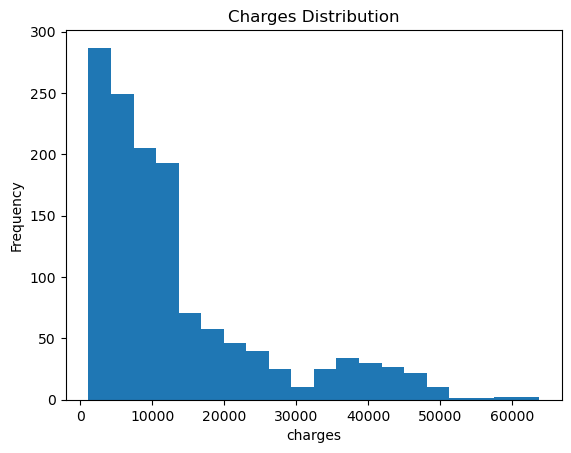

In [14]:
# Histogram of charges
plt.figure()
plt.hist(df['charges'], bins = 20)
plt.title("Charges Distribution")
plt.xlabel("charges")
plt.ylabel("Frequency")
plt.show()

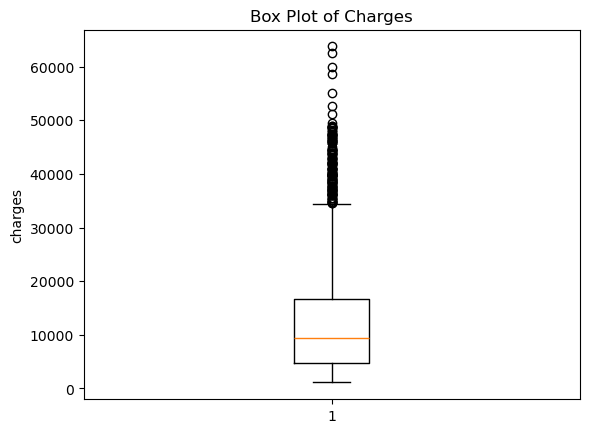

In [15]:
# box plot for charges

plt.figure()
plt.boxplot(df['charges'])
plt.title("Box Plot of Charges")
plt.ylabel("charges")
plt.show()

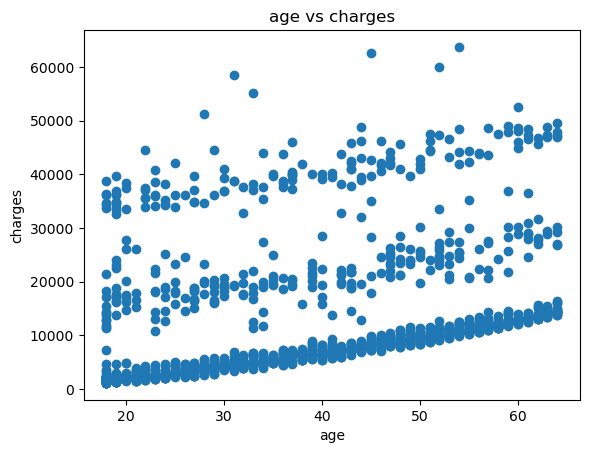

In [16]:
# Scatter plot age vs charges

plt.figure()
plt.scatter(df['age'], df['charges'])
plt.title("age vs charges")
plt.xlabel("age")
plt.ylabel("charges")
plt.show()

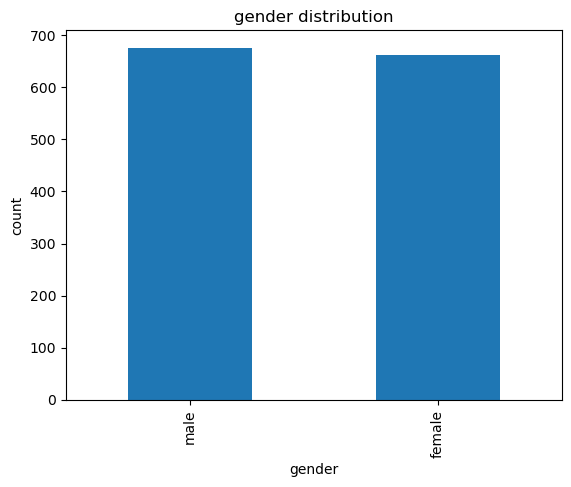

In [18]:
# bar chart of gender distribution / count

plt.figure()
df['sex'].value_counts().plot(kind = 'bar')
plt.title("gender distribution")
plt.xlabel("gender")
plt.ylabel("count")
plt.show()



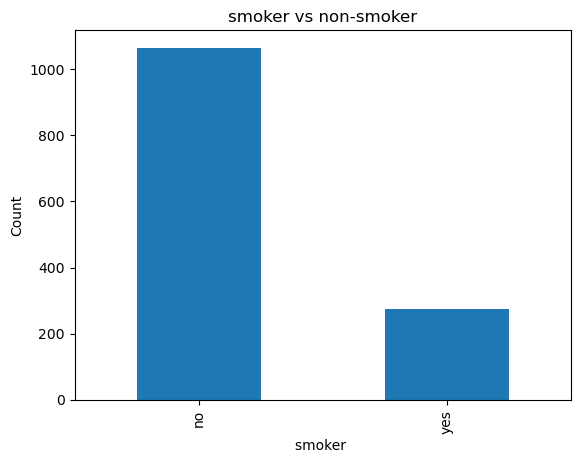

In [20]:
plt.figure()
df['smoker'].value_counts().plot(kind ='bar')
plt.title("smoker vs non-smoker")
plt.xlabel("smoker ")
plt.ylabel("Count")
plt.show()

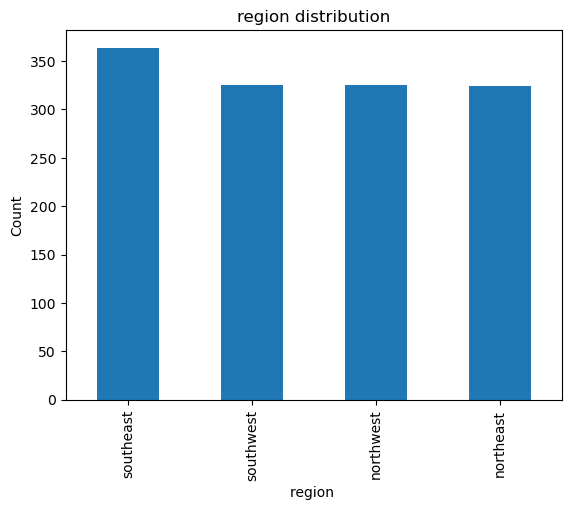

In [21]:
plt.figure()
df['region'].value_counts().plot(kind ='bar')
plt.title("region distribution")
plt.xlabel("region ")
plt.ylabel("Count")
plt.show() 

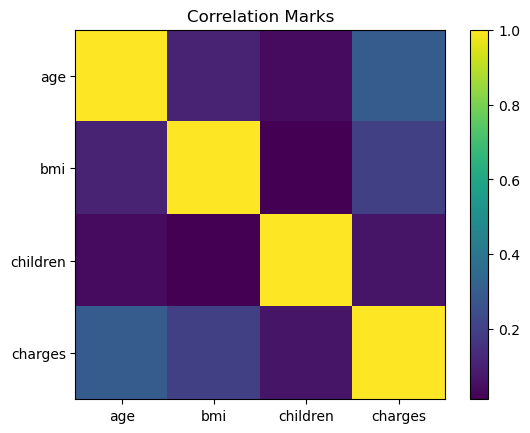

In [28]:
# correlation heatmap

plt.figure()
corr = df.corr(numeric_only = True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Marks")
plt.show()



In [31]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# ridge and lasso are types of LR(linear regression)
# ridge = for avoid over fitting
# lasso = for under feature / over feature

In [32]:
df.corr(numeric_only= True)


,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [33]:
# from above absolute value we can calculate

abs(df.corr(numeric_only = True))['charges'].sort_values(ascending =False)



charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

In [ ]:
# outlier detection

